In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [7]:
df = pd.read_csv('C://Users//pamul//Downloads//spam.csv', encoding='latin-1')

In [11]:
#Keep only the label and text columns, and rename them for clarity

In [9]:
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
#Convert labels to numbers: Ham = 0, Spam = 1
df['label_bin'] = df['label'].map({'ham': 0, 'spam': 1})

In [29]:
df['label_bin'] = df['label'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label_bin'], test_size=0.2, random_state=42
)

In [27]:
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [23]:
y_pred = model.predict(X_test_tfidf)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 96.68%

Detailed Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [31]:
def check_message(message):
    data = tfidf.transform([message])
    result = model.predict(data)
    return "SPAM" if result[0] == 1 else "HAM"

In [33]:
print("--- Testing the model ---")
msg1 = "WINNER! You have won a 1000 dollar prize. Call now to claim!"
msg2 = "Hey, are you coming to the football game tonight?"

print(f"Message 1: {check_message(msg1)}")
print(f"Message 2: {check_message(msg2)}")

--- Testing the model ---
Message 1: SPAM
Message 2: HAM


In [63]:
df['is_spam'] = model.predict(X)

ham_only_emails = df[df['is_spam'] == 0][['message']]

ham_only_emails.to_csv('cleaned_ham_emails.csv', index=False)
print("Spam deleted! Your ham-only file is ready.")

Spam deleted! Your ham-only file is ready.


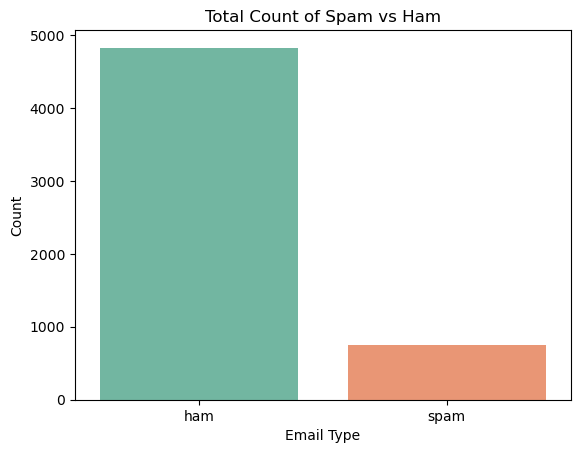

In [65]:
sns.countplot(x='label', data=df, hue='label', palette='Set2', legend=False)
plt.title('Total Count of Spam vs Ham')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.savefig('label_distribution.png')
plt.show()

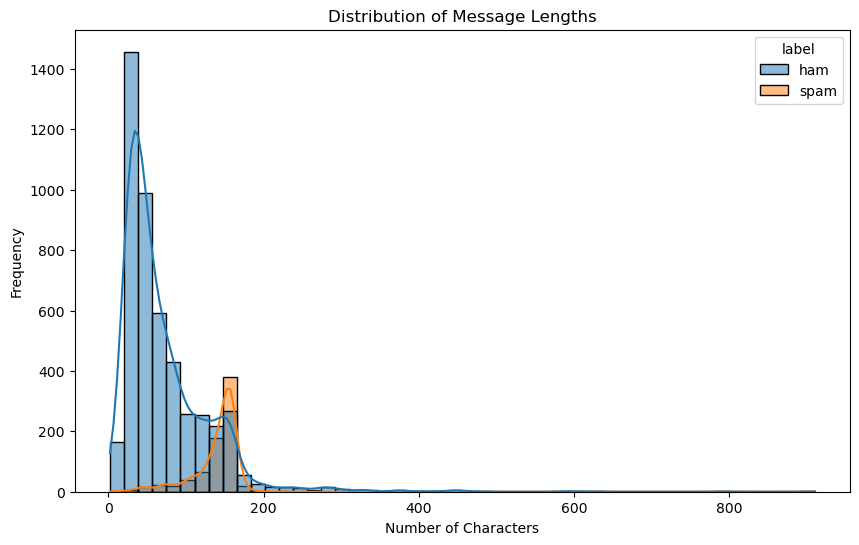

In [59]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True)
plt.title('Distribution of Message Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.savefig('message_length_distribution.png')
plt.show()

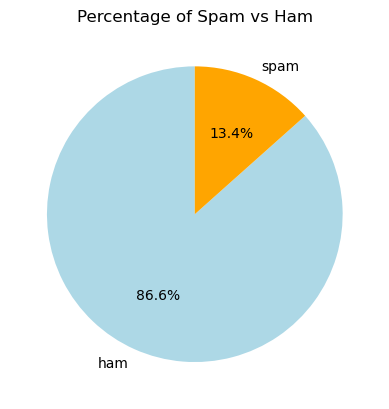

In [55]:
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
plt.title('Percentage of Spam vs Ham')
plt.ylabel('') 
plt.savefig('label_pie_chart.png')
plt.show()